#1.Perkenalan

```html
Live code 5

Nama  : Mardi Wicaksana
Batch : CODA-RMT-016

Program ini dibuat untuk melakukan analisis Time series dan forecast dari data pulaupari
```

#2.Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


#3.Data Loading

In [5]:
datapari = pd.read_csv('multiTimeline.csv')

In [6]:
datapari['Week'] = datapari['Week'].astype('datetime64[ns]')

In [7]:
datapari

,Week,PulauPari
0,2022-03-27,16
1,2022-04-03,13
2,2022-04-10,18
3,2022-04-17,29
4,2022-04-24,35
...,...,...
121,2024-07-21,43
122,2024-07-28,34
123,2024-08-04,32
124,2024-08-11,36


In [8]:
datapari = datapari.set_index('Week')

In [9]:
datapari.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 126 entries, 2022-03-27 to 2024-08-18
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   PulauPari  126 non-null    int64
dtypes: int64(1)
memory usage: 2.0 KB


# 4.Exploratory Data Analysis (EDA)

<Axes: xlabel='Week'>

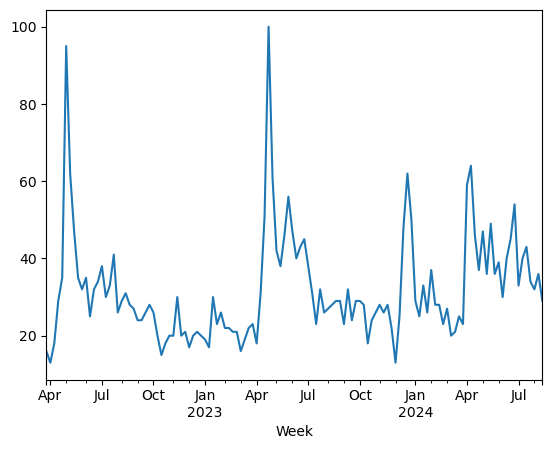

In [10]:
datapari['PulauPari'].plot()

terlihat bahwa data pattern seasonal populasi pulau pari meningkat di bulan april-juni 90-100 dari 2022 sampai 2023 dan di 2024 populasi tetap meningkat tinggi tetapi tidak sebanyak di tahun 2022 dan 2023

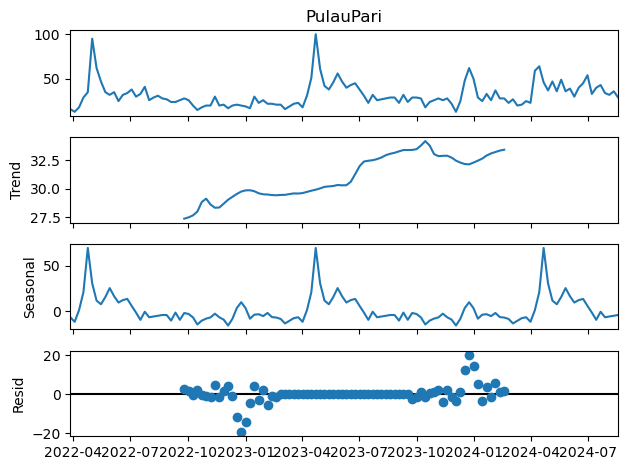

In [11]:
res = seasonal_decompose(datapari['PulauPari'], model='additive')
ax=res.plot()
plt.show()

terlihat dari table decompose pulau pari, dari trend terlihat terjadinya peningkatan adanya growth setiap tahunya,
dari seasonal terlihat data memiliki pola yang sama menandakan  bahwa pulaupari memiliki banyak populasi di saat bulan tertentu saja
Resid menunjukan bahwa data pengunjung memiliki outlier yang tinggi mencapai -20 di tahun 2023 bulan 1, dan ada outlier 20 di tahun 2024 bulan 1 maka bisa dinyatakan bahwa model additive tidak bisa dipakai karena di datapariresidunya memiliki outlier yang sangat tinggi

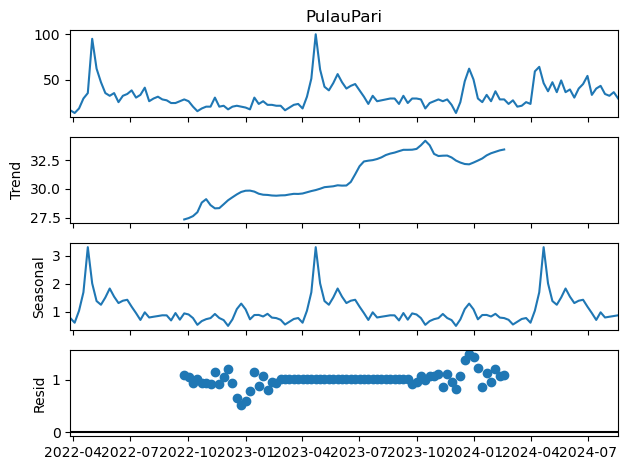

In [12]:
res = seasonal_decompose(datapari['PulauPari'], model='multiplicative')
ax=res.plot()
plt.show()

dari tabel grafik model multiplicative pola dari grafik ori, trend, seasonal memiliki kesamaan seperti additive, tetapi dari grafik resid berbeda dibandingkan dengan model additive tadi, di model multiplicative terlihat sudah lebih sedikit stabil tidak terlalu banyak terlihat outlier maka model multiplicative dapat dijadikan acuan untuk mempresentasikan data.

In [13]:
seasonal_max = res.seasonal[res.seasonal==res.seasonal.max()].reset_index()
seasonal_min = res.seasonal[res.seasonal==res.seasonal.min()].reset_index()
seasonal_max.head()

,Week,seasonal
0,2022-04-24,3.303952
1,2023-04-23,3.303952
2,2024-04-21,3.303952


setelah di dapatkan nilai seasonal maka asumsi sebelumnya benar yaitu tahunan, karena puncaknya populasi berada di bulan 4 setiap tahunnya.

In [14]:
seasonal_max['Week'].dt.day_of_week.head() 

0    6
1    6
2    6
Name: Week, dtype: int32

setelah mengekstrak puncaknya populasi berada di hari sabtu

In [15]:
def check_stationarity(series):
    # Copied from https://machinelearningmastery.com/time-series-data-stationary-python/

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [32]:
check_stationarity(datapari['PulauPari'])

ADF Statistic: -3.893116
p-value: 0.002086
Critical Values:
	1%: -3.485
	5%: -2.886
	10%: -2.580
Stationary


setelah di check data stationer data menunjukan data pulaupari itu stationer dari nilai p value < 0.05

# 6. Model Definition and Training

In [55]:
model = ARIMA(datapari["PulauPari"].asfreq('W'), order=(1, 0, 0)) ##karena data stationer langsung berhasil maka tidak ada dilakukannya differensial, maka nilai Dnya 0
result = model.fit()
print('AIC:',result.aic)
prediksi = result.predict(start=0,end=len(datapari)-1)

AIC: 961.2750910822211


# 7. Model Evaluation

In [35]:
print('MSE:',mean_squared_error(datapari['PulauPari'], prediksi))
print('MAE:',mean_absolute_error(datapari['PulauPari'], prediksi))

MSE: 115.17870080853501
MAE: 6.863503182214561


didapatkan data arima, dari AIC : 961.2750910822211, dan MSE: 115.17 MAE: 6.86 dari data ini kita masih belum mengetahui apakah data ini sudah akurat atau masih bisa di gali lagi data yang lebih terkecil nilai AIC MSE dan MAEnya, karena jika nilai semakin kecil data semakin akurat

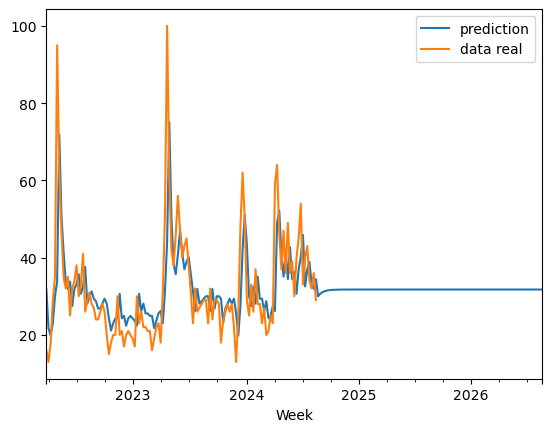

In [49]:
result.predict(0, len(datapari)+104).plot(label='prediction')
datapari['PulauPari'].plot(label='data real')
plt.legend()

data belum menunjukkan  prediksi penuh maka dilakukan fine tunning

# 7.Model Improvement

In [50]:
def find_best_model(data, num_p, num_d, num_q):
  df = pd.DataFrame() #We make a pandas dataframe to ease our work, you can use any way that makes you comfortable and work easly
  pdq = [[],[],[]] #This list for storing the combinations of p and q
  aic = [] # This list for storing aic value
  for p in range(num_p + 1): #plus one is to make the range up to num_p since python range only ranging from 0 to N-1
    for d in range(num_d + 1):
      for q in range(num_q + 1):
        # #if p!=0 and q!=0: #this logic will avoid (0,0) value which is not correct
        try: #Using exception to avoid the error while training the model with certain p and q value
          model = ARIMA(data, order=(p, d, q))
          result = model.fit()
          pdq[0].append(p)
          pdq[1].append(d)
          pdq[2].append(q)
          aic.append(result.aic)
        except:
          pass #If there is an error caused by the calculation, it will be skipped to the next iteration

  df['p'] = pdq[0]
  df['d'] = pdq[1]
  df['q'] = pdq[2]
  df['AIC'] = aic

  df.sort_values('AIC', inplace=True)

  return df.p.iloc[0], df.d.iloc[0], df.q.iloc[0], df.AIC.iloc[0], df

In [51]:
p,d,q,AIC,df = find_best_model(datapari['PulauPari'].asfreq('W'), 10, 0, 10)

d:\A1BELAJAR\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\A1BELAJAR\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\A1BELAJAR\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\A1BELAJAR\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\A1BELAJAR\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood op

melakukan tuning dengan 10x10 percobaan dari p, d, q, dan AIC agar mendapatkan tingkat akurasi data yang bagus

In [52]:
df.head()

,p,d,q,AIC
11,1,0,0,961.275091
2,0,0,2,961.604941
22,2,0,0,962.162996
13,1,0,2,962.336499
12,1,0,1,962.366513


data row pertama (67) terlihat AICnya memiliki nilai lebih kecil 22.00, Dalam Rumus ARIMA jika AIC nilaianya semakin kecil maka tingkat akurasi datanya semakin bagus, maka di ambil row 1 dengan nilai aic 22.00


In [54]:
model = ARIMA(datapari['PulauPari'].asfreq('W'), order=(1, 0, 0))
result = model.fit()

prediksi = result.predict(start=0,end=len(datapari)-1)

print('MSE:',mean_squared_error(datapari['PulauPari'], prediksi))
print('MAE:',mean_absolute_error(datapari['PulauPari'], prediksi))

MSE: 115.17870080853501
MAE: 6.863503182214561


MSE: 115.17870080853501
MAE: 6.863503182214561

Dilihat dari Data AIC.MSE,MAE sebelumnya AIC : 961.2750910822211, dan MSE: 115.17 MAE: 6.86
dan yang terbaru AIC : 961.275091 MSE: 115.17870080853501 MAE: 6.863503182214561, Tidak memiliki perbedaan AIC berarti data yang di ambil sudah yang paling terkecil dan sudah akurat

# 8.Model Inference

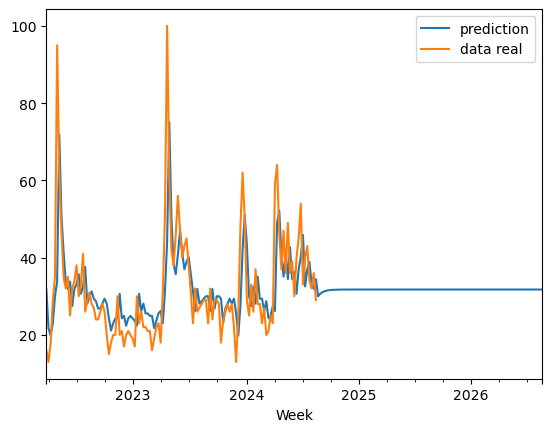

In [58]:
result.predict(0, len(datapari)+104).plot(label='prediction')
datapari['PulauPari'].plot(label='data real')
plt.legend()

Dari hasil prediksi menggunakan ARIMA (1,0,0), terlihat bahwa model sudah cukup mengikuti pola data historis yang ada, termasuk pola pada tahun 2024. Namun, hasil prediksi masih belum sepenuhnya menangkap lonjakan kenaikan yang cukup tinggi pada periode tertentu. Pada hasil forecast ke depan, pola data terlihat cenderung stabil di sekitar nilai rata-rata, sehingga prediksi yang dihasilkan tidak terlalu mengalami kenaikan atau penurunan ekstrem dan lebih mengikuti pola rata-rata dari data sebelumnya.